# Exercise 1: Variational autoencoders
Exercise by [Jes Frellsen](https://frellsen.org) (Technical University of Denmark), June 2026 (version 1.11).

In this programming exercise, you will work with variational autoencoders (VAEs). We consider a binarised version of the MNIST dataset, where pixels with values over $0.5$ are set to $1$ and pixels with values less than $0.5$ are set to $0$.

The provided code is a modular and simple implementation of a VAE with
* a Gaussian prior, $p(\mathbf{z})$,
* a product of Bernoulli likelihood, $p(\mathbf{x}|\mathbf{z})$,
* a fully connected encoder and decoder network.

The implementation makes use of [`torch.distributions`](https://pytorch.org/docs/stable/distributions.html) for the various distributions, which substantially simplifies the code.

The code is followed by three exercises you have to solve.

This implementation in the notebook takes inspiration from:
* https://github.com/jmtomczak/intro_dgm/blob/main/vaes/vae_example.ipynb
* https://github.com/kampta/pytorch-distributions/blob/master/gaussian_vae.py

## Implementing the VAE
**VAE implementation:** Below we provide a complete implementation of the VAE.

In [1]:
import torch
import torch.nn as nn
import torch.distributions as td

class GaussianPrior(nn.Module):
    def __init__(self, M):
        """
        Define a Gaussian prior distribution with zero mean and unit variance.

                Parameters:
        M: [int] 
           Dimension of the latent space.
        """
        super(GaussianPrior, self).__init__()
        self.M = M
        self.mean = nn.Parameter(torch.zeros(self.M), requires_grad=False)
        self.std = nn.Parameter(torch.ones(self.M), requires_grad=False)

    def forward(self):
        """
        Return the prior distribution.

        Returns:
        prior: [torch.distributions.Distribution]
        """
        return td.Independent(td.Normal(loc=self.mean, scale=self.std), 1)


class GaussianEncoder(nn.Module):
    def __init__(self, encoder_net):
        """
        Define a Gaussian encoder distribution based on a given encoder network.

        Parameters:
        encoder_net: [torch.nn.Module]             
           The encoder network that takes as a tensor of dim `(batch_size,
           feature_dim1, feature_dim2)` and output a tensor of dimension
           `(batch_size, 2M)`, where M is the dimension of the latent space.
        """
        super(GaussianEncoder, self).__init__()
        self.encoder_net = encoder_net

    def forward(self, x):
        """
        Given a batch of data, return a Gaussian distribution over the latent space.

        Parameters:
        x: [torch.Tensor] 
           A tensor of dimension `(batch_size, feature_dim1, feature_dim2)`
        """
        mean, std = torch.chunk(self.encoder_net(x), 2, dim=-1)
        return td.Independent(td.Normal(loc=mean, scale=torch.exp(std)), 1)


class BernoulliDecoder(nn.Module):
    def __init__(self, decoder_net):
        """
        Define a Bernoulli decoder distribution based on a given decoder network.

        Parameters: 
        encoder_net: [torch.nn.Module]             
           The decoder network that takes as a tensor of dim `(batch_size, M) as
           input, where M is the dimension of the latent space, and outputs a
           tensor of dimension (batch_size, feature_dim1, feature_dim2).
        """
        super(BernoulliDecoder, self).__init__()
        self.decoder_net = decoder_net

    def forward(self, z):
        """
        Given a batch of latent variables, return a Bernoulli distribution over the data space.

        Parameters:
        z: [torch.Tensor] 
           A tensor of dimension `(batch_size, M)`, where M is the dimension of the latent space.
        """
        logits = self.decoder_net(z)
        return td.Independent(td.Bernoulli(logits=logits), 2)


class VAE(nn.Module):
    """
    Define a Variational Autoencoder (VAE) model.
    """
    def __init__(self, prior, decoder, encoder):
        """
        Parameters:
        prior: [torch.nn.Module] 
           The prior distribution over the latent space.
        decoder: [torch.nn.Module]
              The decoder distribution over the data space.
        encoder: [torch.nn.Module]
                The encoder distribution over the latent space.
        """
            
        super(VAE, self).__init__()
        self.prior = prior
        self.decoder = decoder
        self.encoder = encoder

    def elbo(self, x):
        """
        Compute the ELBO for the given batch of data.

        Parameters:
        x: [torch.Tensor] 
           A tensor of dimension `(batch_size, feature_dim1, feature_dim2, ...)`
           n_samples: [int]
           Number of samples to use for the Monte Carlo estimate of the ELBO.
        """
        q = self.encoder(x)
        z = q.rsample()
        elbo = torch.mean(self.decoder(z).log_prob(x) - td.kl_divergence(q, self.prior()), dim=0)
        return elbo

    def sample(self, n_samples=1):
        """
        Sample from the model.
        
        Parameters:
        n_samples: [int]
           Number of samples to generate.
        """
        z = self.prior().sample(torch.Size([n_samples]))
        return self.decoder(z).sample()
    
    def forward(self, x):
        """
        Compute the negative ELBO for the given batch of data.

        Parameters:
        x: [torch.Tensor] 
           A tensor of dimension `(batch_size, feature_dim1, feature_dim2)`
        """
        return -self.elbo(x)

**Training loop**: We have also implemented a generic training loop for learning the VAE model.

In [2]:
from tqdm.notebook import tqdm

def train(model, optimizer, data_loader, epochs, device):
    """
    Train a Flow model.

    Parameters:
    model: [Flow]
       The model to train.
    optimizer: [torch.optim.Optimizer]
         The optimizer to use for training.
    data_loader: [torch.utils.data.DataLoader]
            The data loader to use for training.
    epochs: [int]
        Number of epochs to train for.
    device: [torch.device]
        The device to use for training.
    """
    model.train()

    total_steps = len(data_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")

    for epoch in range(epochs):
        data_iter = iter(data_loader)
        for x in data_iter:
            if isinstance(x, (list, tuple)):
                x = x[0]
            x = x.to(device)
            optimizer.zero_grad()
            loss = model(x)
            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

**Training data**: Next, we load MNIST as binarized at `thresshold` and create data loaders for training and test.

In [3]:
from torchvision import datasets, transforms

batch_size = 32
thresshold = 0.5
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: (thresshold < x).float().squeeze())])

mnist_train_loader = torch.utils.data.DataLoader(datasets.MNIST('data/', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
mnist_test_loader = torch.utils.data.DataLoader(datasets.MNIST('data/', train=False, download=True, transform=transform), batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 301kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.74MB/s]


**Initialize the model and run the training loop**: Finally we initialize the model using a simple fully connected encoder and decoder networks and run the training loop. The networks are very simple to keep training time low.

In [4]:
# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define prior distribution with dimension M
M = 2
prior = GaussianPrior(M)

# Define encoder and decoder networks (fully connected)
encoder_net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, M*2),
)

decoder_net = nn.Sequential(
    nn.Linear(M, 128),
    nn.ReLU(),
    nn.Linear(128, 784),
    nn.Unflatten(-1, (28, 28))
)

# Define VAE model
decoder = BernoulliDecoder(decoder_net)
encoder = GaussianEncoder(encoder_net)
model = VAE(prior, decoder, encoder).to(device)

# Define optimizer
optimizer = torch.optim.Adam(model.parameters())

# Train model
epochs = 10
train(model, optimizer, mnist_train_loader, epochs, device)

Training:   0%|          | 0/18750 [00:00<?, ?it/s]

**Sampling**: The following code samples from a trained model and plots the samples

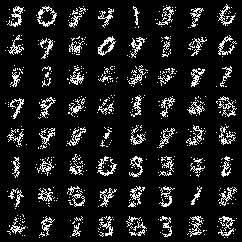

In [5]:
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import make_grid
from IPython.display import display

model.eval()
with torch.no_grad():
    samples = (model.sample(64)).cpu()

image_pil = to_pil_image(make_grid(samples.view(-1, 1, 28, 28)))
display(image_pil)

## Exercises

### Exercise 1.1

In this first exercise, you should just inspect the VAE code above and answer the following questions:
* How is the reparametrisation trick handled in the code?
* Consider the implementation of the ELBO. What are the dimensions of `self.decoder(z).log_prob(x)` and of `td.kl_divergence(q, self.prior.distribuion)`?
* The implementation of the prior, encoder and decoder classes all make use of `td.Independent`. What does this do?
* What is the purpose using the function `torch.chunk` in `GaussianEncoder.forward`?

#### Answers to Exercise 1.1

**How is the reparameterisation trick handled in the code?**

It is handled via `q.rsample()` in the `elbo` method. The `rsample()` method (as opposed to `sample()`) uses the reparameterization trick internally: for a Gaussian `q = N(μ, σ²)`, it samples `ε ~ N(0, I)` and returns `z = μ + σ ⊙ ε`. This makes `z` a deterministic, differentiable function of the distribution parameters `μ` and `σ`, so gradients can flow through `z` back to the encoder.

**What are the dimensions of `self.decoder(z).log_prob(x)` and `td.kl_divergence(q, self.prior())`?**

Both are tensors of shape `(batch_size,)`. The decoder returns an `Independent(Bernoulli(...), 2)` distribution, so `log_prob(x)` sums over both spatial dimensions (28×28), producing one scalar per sample. Similarly, `td.kl_divergence(q, self.prior())` computes the KL divergence between two `Independent(Normal(...), 1)` distributions, which sums over the M latent dimensions, yielding one scalar per sample.

**What does `td.Independent` do?**

`td.Independent` reinterprets some of the batch dimensions of a distribution as event dimensions. For example, `td.Independent(td.Normal(loc, scale), 1)` converts a batch of M independent 1D normals into a single M-dimensional distribution with a diagonal covariance. This means `log_prob` returns the *sum* of the individual log-probabilities across the reinterpreted dimensions, rather than a vector. Similarly, `td.Independent(td.Bernoulli(...), 2)` sums over two dimensions (the 28×28 pixel grid).

**What is the purpose of `torch.chunk` in `GaussianEncoder.forward`?**

`torch.chunk(self.encoder_net(x), 2, dim=-1)` splits the encoder network output (of size `2M`) into two equal halves along the last dimension. The first half is the mean `μ` and the second half is the (log) standard deviation of the approximate posterior `q(z|x)`. This is a common pattern to produce both parameters from a single network forward pass.

### Exercise 1.2

In the VAE implementation of the ELBO, we sample the latent variable using

```python
q = self.encoder(x)
z = q.rsample()
```

The method `rsample()` performs the **reparameterization trick**, which allows gradients to flow through the sampling operation.

* Rewrite the code above by **implementing the reparameterisation trick explicitly**.

For a Gaussian distribution with **diagonal covariance** $\mathrm{diag}(\sigma)$, a sample can be written as
$$
\mathbf{z} = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I),
$$
where $\mu$ and $\sigma$ are vectors and $\odot$ denotes element-wise multiplication.

Your task is therefore to:

1. Extract the mean and standard deviation from `q`.
2. Sample noise $\epsilon$ from a standard normal distribution.
3. Construct the latent variable `z` using the reparameterisation formula.

You may find the following PyTorch functions useful:

- `torch.randn_like`
- `q.loc`
- `q.scale`

In [6]:
# Exercise 1.2: Explicit reparameterization trick

class VAE_explicit_reparam(VAE):
    """VAE with explicit reparameterization trick in the ELBO."""
    
    def elbo(self, x):
        q = self.encoder(x)
        
        # Explicit reparameterization trick:
        # Instead of z = q.rsample(), we do:
        mu = q.base_dist.loc        # mean of the Gaussian
        sigma = q.base_dist.scale   # std of the Gaussian
        epsilon = torch.randn_like(mu)  # sample noise from N(0, I)
        z = mu + sigma * epsilon        # reparameterized sample
        
        elbo = torch.mean(self.decoder(z).log_prob(x) - td.kl_divergence(q, self.prior()), dim=0)
        return elbo

# Quick verification: train for 1 epoch with explicit reparam
model_reparam = VAE_explicit_reparam(
    GaussianPrior(M),
    BernoulliDecoder(
        nn.Sequential(
            nn.Linear(M, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Unflatten(-1, (28, 28))
        )
    ),
    GaussianEncoder(
        nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, M*2),
        )
    )
).to(device)

optimizer_reparam = torch.optim.Adam(model_reparam.parameters())
train(model_reparam, optimizer_reparam, mnist_train_loader, 1, device)
print("Exercise 1.2: Explicit reparameterization trick works correctly.")

Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Exercise 1.2: Explicit reparameterization trick works correctly.


### Exercise 1.3

Add the following functionally to the implementation of the VAE with Bernoulli output distributions:
* Evaluate the ELBO on the binarised MNIST test set.
* Plot samples from the approximate posterior and colour them by their correct class label for each datapoint in the test set (i.e., samples from the aggregate posterior) for a two-dimensional latent space, i.e., $M=2$.
* *Optional:* The decoder and encoder networks above are very simple. Try to make the model more expressive by making the networks wider/deeper and increase the dimension of the latent space. Plot the aggregate posterior for $M>2$ by doing PCA and project the sample onto the first two principal components (e.g., using scikit-learn).


Average test set ELBO: -151.58


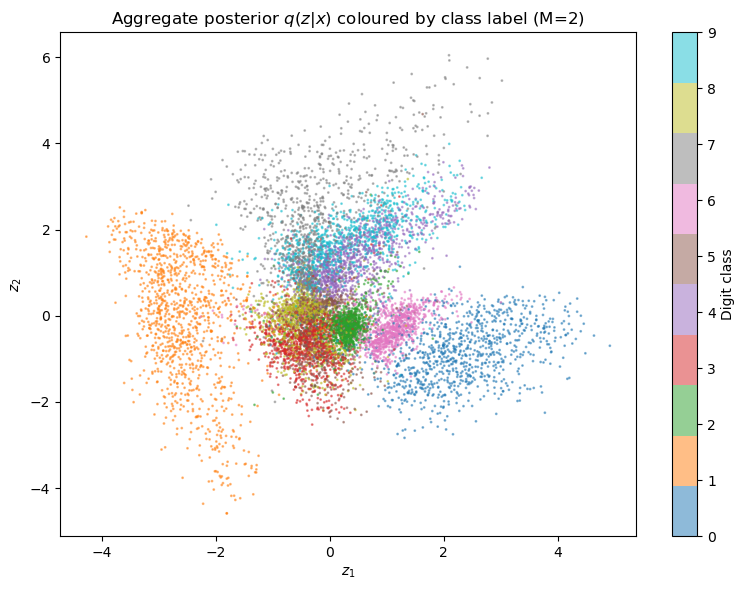

In [7]:
# Exercise 1.3: Evaluate test ELBO and plot aggregate posterior

import numpy as np
import matplotlib.pyplot as plt

# --- Evaluate ELBO on the binarised MNIST test set ---
model.eval()
total_elbo = 0.0
total_samples = 0

with torch.no_grad():
    for x, _ in mnist_test_loader:
        x = x.to(device)
        q = model.encoder(x)
        z = q.rsample()
        elbo = (model.decoder(z).log_prob(x) - td.kl_divergence(q, model.prior()))
        total_elbo += elbo.sum().item()
        total_samples += x.size(0)

avg_test_elbo = total_elbo / total_samples
print(f"Average test set ELBO: {avg_test_elbo:.2f}")

# --- Plot samples from the aggregate posterior coloured by class label ---
all_z = []
all_labels = []

with torch.no_grad():
    for x, labels in mnist_test_loader:
        x = x.to(device)
        q = model.encoder(x)
        z = q.rsample()
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

all_z = np.concatenate(all_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap='tab10', s=1, alpha=0.5)
plt.colorbar(scatter, ticks=range(10), label='Digit class')
plt.xlabel('$z_1$')
plt.ylabel('$z_2$')
plt.title('Aggregate posterior $q(z|x)$ coloured by class label (M=2)')
plt.tight_layout()
plt.show()

Training:   0%|          | 0/18750 [00:00<?, ?it/s]

Average test set ELBO (M=10, deeper net): -93.11


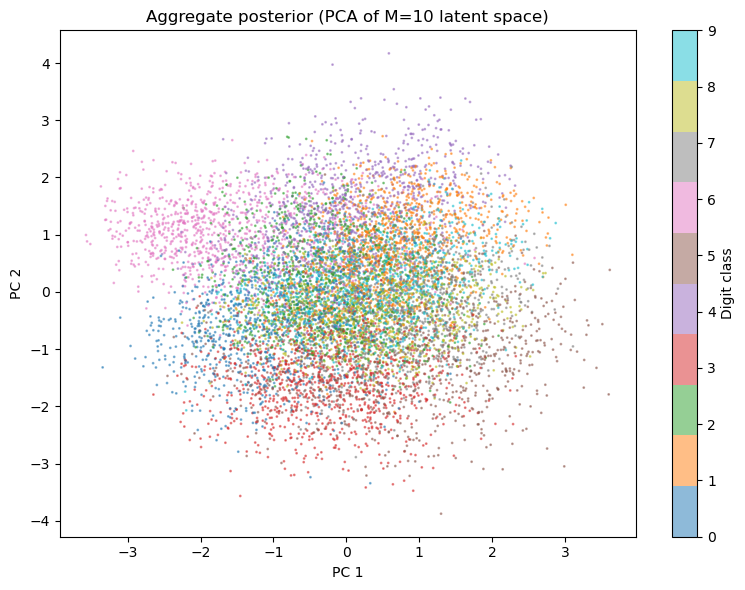

In [8]:
# Exercise 1.3 (Optional): Wider/deeper networks with M>2 and PCA visualization

from sklearn.decomposition import PCA

M_large = 10

# Deeper encoder and decoder
encoder_net_deep = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, M_large * 2),
)

decoder_net_deep = nn.Sequential(
    nn.Linear(M_large, 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Unflatten(-1, (28, 28))
)

model_deep = VAE(
    GaussianPrior(M_large),
    BernoulliDecoder(decoder_net_deep),
    GaussianEncoder(encoder_net_deep)
).to(device)

optimizer_deep = torch.optim.Adam(model_deep.parameters())
train(model_deep, optimizer_deep, mnist_train_loader, 10, device)

# Evaluate test ELBO
model_deep.eval()
total_elbo_deep = 0.0
total_samples_deep = 0

with torch.no_grad():
    for x, _ in mnist_test_loader:
        x = x.to(device)
        q = model_deep.encoder(x)
        z = q.rsample()
        elbo = (model_deep.decoder(z).log_prob(x) - td.kl_divergence(q, model_deep.prior()))
        total_elbo_deep += elbo.sum().item()
        total_samples_deep += x.size(0)

print(f"Average test set ELBO (M={M_large}, deeper net): {total_elbo_deep / total_samples_deep:.2f}")

# Collect latent representations and project with PCA
all_z_deep = []
all_labels_deep = []

with torch.no_grad():
    for x, labels in mnist_test_loader:
        x = x.to(device)
        q = model_deep.encoder(x)
        z = q.rsample()
        all_z_deep.append(z.cpu().numpy())
        all_labels_deep.append(labels.numpy())

all_z_deep = np.concatenate(all_z_deep, axis=0)
all_labels_deep = np.concatenate(all_labels_deep, axis=0)

pca = PCA(n_components=2)
z_pca = pca.fit_transform(all_z_deep)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_pca[:, 0], z_pca[:, 1], c=all_labels_deep, cmap='tab10', s=1, alpha=0.5)
plt.colorbar(scatter, ticks=range(10), label='Digit class')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title(f'Aggregate posterior (PCA of M={M_large} latent space)')
plt.tight_layout()
plt.show()

### Exercise 1.4

Extend the VAE with Bernoulli output distributions to use a mixture of Gaussian prior (MoG). We recommend using the [`MixtureSameFamily`](https://pytorch.org/docs/stable/distributions.html#mixturesamefamily) class from [`torch.distributions`](https://pytorch.org/docs/stable/distributions.html), but you are also welcome to implement it from scratch. For your implementation of the VAE with the MoG prior:
* Evaluate the test set ELBO. Do you see better performance?
* Plot the samples from the aggregate posterior. How does it differ from the model with the Gaussian prior? Do you see better clustering?

**Remark**: You will need to change the implementation of the ELBO.

In [9]:
# Exercise 1.4: VAE with Mixture of Gaussians (MoG) prior

class MoGPrior(nn.Module):
    def __init__(self, M, K):
        """
        Define a Mixture of Gaussians prior distribution.

        Parameters:
        M: [int] Dimension of the latent space.
        K: [int] Number of mixture components.
        """
        super(MoGPrior, self).__init__()
        self.M = M
        self.K = K
        # Learnable mixture logits, means and log-stds
        self.logits = nn.Parameter(torch.zeros(K))
        self.means = nn.Parameter(torch.randn(K, M))
        self.log_stds = nn.Parameter(torch.zeros(K, M))

    def forward(self):
        """
        Return the MoG prior distribution.

        Returns:
        prior: [torch.distributions.Distribution]
        """
        mix = td.Categorical(logits=self.logits)
        comp = td.Independent(td.Normal(loc=self.means, scale=torch.exp(self.log_stds)), 1)
        return td.MixtureSameFamily(mix, comp)


class VAE_MoG(nn.Module):
    """
    VAE with a Mixture of Gaussians prior.
    The ELBO uses Monte Carlo estimation of the KL divergence since
    the KL between a Gaussian and a MoG has no closed form.
    """
    def __init__(self, prior, decoder, encoder):
        super(VAE_MoG, self).__init__()
        self.prior = prior
        self.decoder = decoder
        self.encoder = encoder

    def elbo(self, x):
        q = self.encoder(x)
        z = q.rsample()
        # Monte Carlo estimate of ELBO: E_q[log p(x|z) + log p(z) - log q(z|x)]
        log_p_x_given_z = self.decoder(z).log_prob(x)
        log_p_z = self.prior().log_prob(z)
        log_q_z_given_x = q.log_prob(z)
        elbo = torch.mean(log_p_x_given_z + log_p_z - log_q_z_given_x, dim=0)
        return elbo

    def sample(self, n_samples=1):
        z = self.prior().sample(torch.Size([n_samples]))
        return self.decoder(z).sample()

    def forward(self, x):
        return -self.elbo(x)


# --- Train VAE with MoG prior (M=2, K=10 components) ---
M_mog = 2
K = 10

encoder_net_mog = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, M_mog * 2),
)

decoder_net_mog = nn.Sequential(
    nn.Linear(M_mog, 128),
    nn.ReLU(),
    nn.Linear(128, 784),
    nn.Unflatten(-1, (28, 28))
)

model_mog = VAE_MoG(
    MoGPrior(M_mog, K),
    BernoulliDecoder(decoder_net_mog),
    GaussianEncoder(encoder_net_mog)
).to(device)

optimizer_mog = torch.optim.Adam(model_mog.parameters())
train(model_mog, optimizer_mog, mnist_train_loader, 10, device)

Training:   0%|          | 0/18750 [00:00<?, ?it/s]

Average test set ELBO (MoG prior, M=2, K=10): -149.63
Average test set ELBO (Gaussian prior, M=2):       -151.58


/tmp/ipykernel_32818/809169597.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


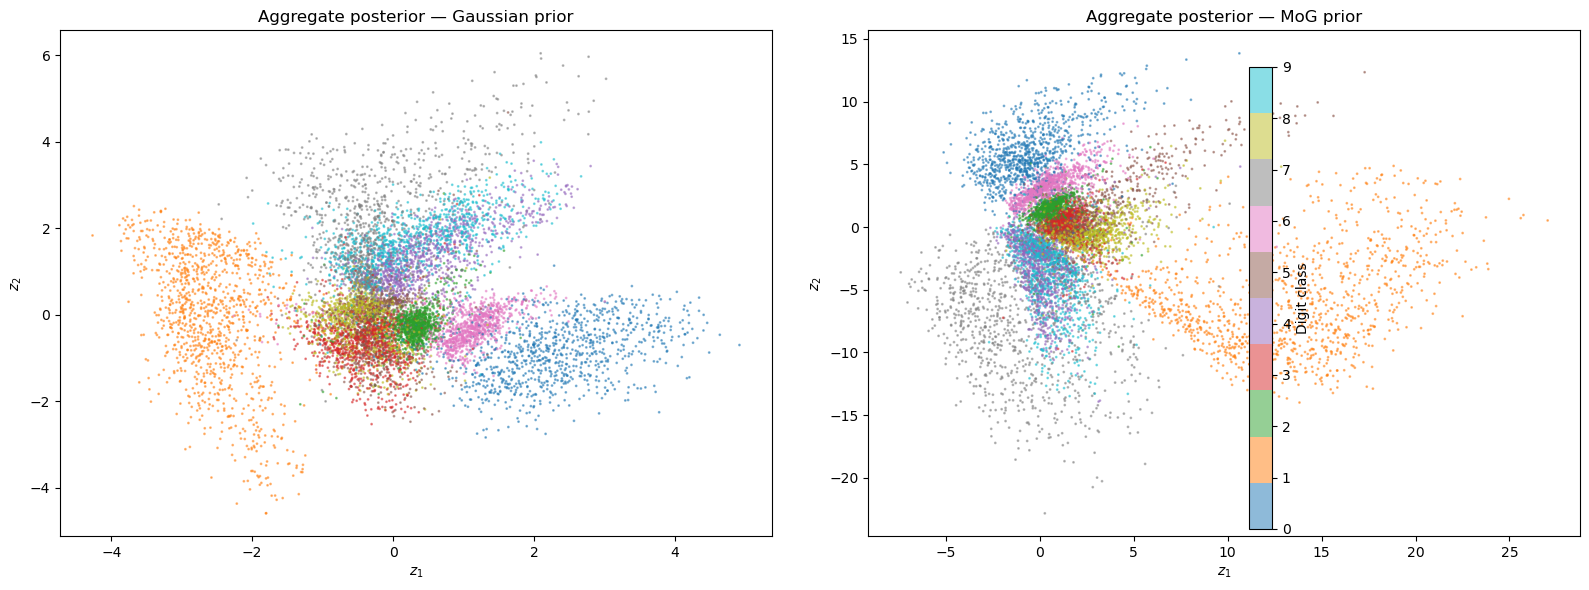

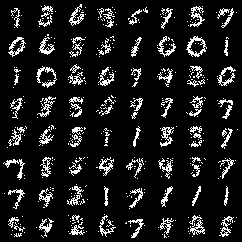

In [10]:
# Exercise 1.4 (continued): Evaluate test ELBO and plot aggregate posterior for MoG VAE

# --- Evaluate test ELBO ---
model_mog.eval()
total_elbo_mog = 0.0
total_samples_mog = 0

with torch.no_grad():
    for x, _ in mnist_test_loader:
        x = x.to(device)
        q = model_mog.encoder(x)
        z = q.rsample()
        log_p_x_given_z = model_mog.decoder(z).log_prob(x)
        log_p_z = model_mog.prior().log_prob(z)
        log_q_z_given_x = q.log_prob(z)
        elbo = log_p_x_given_z + log_p_z - log_q_z_given_x
        total_elbo_mog += elbo.sum().item()
        total_samples_mog += x.size(0)

avg_test_elbo_mog = total_elbo_mog / total_samples_mog
print(f"Average test set ELBO (MoG prior, M={M_mog}, K={K}): {avg_test_elbo_mog:.2f}")
print(f"Average test set ELBO (Gaussian prior, M={M}):       {avg_test_elbo:.2f}")

# --- Plot aggregate posterior coloured by class label ---
all_z_mog = []
all_labels_mog = []

with torch.no_grad():
    for x, labels in mnist_test_loader:
        x = x.to(device)
        q = model_mog.encoder(x)
        z = q.rsample()
        all_z_mog.append(z.cpu().numpy())
        all_labels_mog.append(labels.numpy())

all_z_mog = np.concatenate(all_z_mog, axis=0)
all_labels_mog = np.concatenate(all_labels_mog, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gaussian prior aggregate posterior
axes[0].scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap='tab10', s=1, alpha=0.5)
axes[0].set_xlabel('$z_1$')
axes[0].set_ylabel('$z_2$')
axes[0].set_title('Aggregate posterior — Gaussian prior')

# MoG prior aggregate posterior
scatter = axes[1].scatter(all_z_mog[:, 0], all_z_mog[:, 1], c=all_labels_mog, cmap='tab10', s=1, alpha=0.5)
axes[1].set_xlabel('$z_1$')
axes[1].set_ylabel('$z_2$')
axes[1].set_title('Aggregate posterior — MoG prior')

fig.colorbar(scatter, ax=axes, ticks=range(10), label='Digit class')
plt.tight_layout()
plt.show()

# --- Sample from the MoG model ---
with torch.no_grad():
    samples_mog = model_mog.sample(64).cpu()

image_pil_mog = to_pil_image(make_grid(samples_mog.view(-1, 1, 28, 28)))
display(image_pil_mog)